# Cost Calculations

To calculate the cost of a certain scenario, we follow the approach of Tildesley et al. (2022), with a function incorporating the GDP loss associated with a lockdown, with the loss to society of the deaths and hospitalisations from the outbreak. These are measured by the loss of Quality Adjusted Life Years (QALYs), where the policymakers assign a 'willingness to pay' - an amount of money they deem 1 QALY to be worth. This can range from £20,000 upwards, so I will look at the three scenarios of £20,000, £50,000, and £100,000. The equations are:

$$
\text{Fatal case QALY loss} = 23.5D(1) + 17.6D(2) + 5.3D(3)
$$

$$
\text{Hospitalised QALY loss} = \frac{10}{365} \sum_{a=1}^{3} (H(a) \times Q_w(a)) = \frac{10}{365} ( 0.948H(1) + 0.881H(2) + 0.738H(3))
$$

$$
\text{GDP loss} = \frac{50.2415 \phi - 116.9759 \phi^2 + 90.7837 \phi ^4}{30} \times L \text{  , where } \phi \in [0,1]
$$

Where $a$ is the age group ($a=1$ is 0-19yrs, $a=2$ is 20-64yrs, $a=3$ is 65+), $D(a)$ and $H(a)$ the number of deaths and hospitalisations respectively in the age group $a$, $Q_w(a)$ an age-specific quality of life weighting, and $L$ the number of days in lockdown. The equation for GDP loss comes from fitting a curve to 2020 COVID-19 data (Tildesley et al., 2022), where $\phi$ is the level of control of the lockdown.

The total net monetary loss is found by summing these:

$$
\text{Net monetary loss} = W(\text{fatal + hospitalised QALY losses}) + \frac{50.2415 \phi - 116.9759 \phi^2 + 90.7837 \phi ^4}{30} L
$$

where $W$ is the willingness to pay.

If we denote this net monetary loss for a given vaccine efficacy $\eta$ and lockdown duration $L$ by $\mathcal{C}(\eta, L)$, then the total loss for a lockdown is given by:

$$
\text{Total loss} = \sum_{i=1}^n w_i \mathcal{C}(\eta_i, L)
$$

For $n$ different efficacies {$\eta_1, ... \eta_n$} and their respective weights $w_i$ where $\sum_{j=1}^n w_i =1$.

These weights represent the policymakers' confidence that the vaccine will have that efficacy - likely from clinical trial data or previous similar vaccines, they may be quite certain that the vaccine will have an efficacy of around 70% and that can be represented in its weight $w_i$. If there is no data, you can give them equal weighting - *i.e.* $w_1=...=w_n=\frac{1}{n}$

Here, we will have three different efficacies: $\eta_1 = 0.5, \eta_2 = 0.7, \eta_3 = 0.9$, and therefore three weights $w_1,w_2,w_3$

## Table of contents:

- [Cost simulations for different lockdown times](#costsims)  
  
- [Net monetary loss](#netmoneyloss)  
  > •[$w_1 = w_2 = w_3 = \frac{1}{3}$](#ws=0.3)  
  > •[$w_1 = 0.6$, $w_2 = w_3 = 0.2$](#w1=0.6)  
  > •[$w_2 = 0.6$, $w_1 = w_3 = 0.2$](#w2=0.6)  
  > •[$w_3 = 0.6$, $w_1 = w_2 = 0.2$](#w3=0.6)  

- [Triangle plots](#triangleplots)  
  > •[Willingness to pay £20,000](#w=20k)  
  > •[Willingness to pay £50,000](#w=50k)  
  > •[Willingness to pay £100,000](#w=100k)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import json
from types import SimpleNamespace
import math
import mpltern
import matplotlib.colors as mcolors
import time

import outbreakFunctions # Import the model's two classes: ODEsClass and simAllAges 

In [27]:
f = open("params.json", "r")
contents = f.read()
f.close()

params = json.loads(contents)

youngAgeGrp = params['0-19']
adultAgeGrp = params['20-64']
elderlyAgeGrp = params['65+']

allAgeGrpParams = (youngAgeGrp, adultAgeGrp, elderlyAgeGrp)

## Total cost function

In [3]:
def QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days):
    
    totalCost = 0
    totalQALY = []
    
    for i in range(len(efficaciesArray)):
        simulation = outbreakFunctions.simAllAges(allAgeGrpParams, efficaciesArray[i], vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)
        simulation.ODEsolver( )
        hospY, deadY, vaccY = simulation.outbreakEndResults(0)
        hospA, deadA, vaccA = simulation.outbreakEndResults(1)
        hospE, deadE, vaccE = simulation.outbreakEndResults(2)

        fatalQALY = (23.5*deadY + 17.6*deadA + 5.3*deadE)
        hospQALY = 10/365 * (0.948*hospY + 0.881*hospA + 0.738*hospE)

        totalQALY.append(fatalQALY + hospQALY)
     
    # GDP does not change with efficacy so we can do this outside the for loop:
    monthlyGDPnoLD = 103.6397
    monthlyGDPinLD = 103.6397 - 50.2415*0.5 + 116.9759*(0.5**2) - 90.7837*(0.5**4)
    dailyGDPloss = (monthlyGDPnoLD*(10**9) - monthlyGDPinLD*(10**9))/30
    
    totalGDPloss = dailyGDPloss*((lockdown1End - lockdown1Start) + (lockdown2End - lockdown2Start))
    
    return(totalQALY, totalGDPloss)

# Dependent on willingness to pay - gives the overall net monetary loss
def totalCost(W, totalQALY, totalGDPloss, weights):
    totalCost=0
    for i in range(len(weights)):
        netMonetaryLoss = W*(totalQALY[i]) + totalGDPloss
    
        totalCost += weights[i] * netMonetaryLoss
    return(totalCost)

## Printing cost of lockdowns <a id = "costsims" ></a>

In [8]:
efficaciesArray = [0.5, 0.7, 0.9]
weights = [1/3, 1/3, 1/3]
days = 365
vaccineStart = 70
lockdown1Start = 0
lockdown1End = 0
lockdown2Start = 0
lockdown2End = 0
outbreak2Start = days+1

QALYs, GDP = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1End, lockdown2Start, lockdown2End, outbreak2Start, days)

# for willingness to pay W = £20,000
print("For a W = £20,000, monetary loss is: £", round(totalCost(20000, QALYs, GDP, weights), 2))

# for willingness to pay W = £50,000
print("For a W = £50,000, monetary loss is: £" , round(totalCost(50000, QALYs, GDP, weights), 2))

# for willingness to pay W = £100,000
print("For a W = £100,000, monetary loss is: £", round(totalCost(1000000, QALYs, GDP, weights), 2))

For a W = £20,000, monetary loss is: £ 23099067394.16
For a W = £50,000, monetary loss is: £ 57747668485.39
For a W = £100,000, monetary loss is: £ 1154953369707.76


## Plotting net monetary loss <a id = "netmoneyloss" ></a>

In [12]:
def costsOverLockdowns(efficaciesArray, weights, vaccineStart, lockdown1Start, wks, outbreak2Start, days):
    costArray1_LD1 = []
    costArray2_LD1 = []
    costArray3_LD1 = []
    
    for i in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, 0, 0, outbreak2Start, days)
        
        costArray1_LD1.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD1.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD1.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD1 = [costArray1_LD1, costArray2_LD1, costArray3_LD1]

    # Adding a second 4-week lockdown 20 days after LD1 ends   
    costArray1_LD2_20D = []
    costArray2_LD2_20D = []
    costArray3_LD2_20D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 20, lockdown1Start+j*7 + 48, outbreak2Start, days)

        costArray1_LD2_20D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_20D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_20D.append(totalCost(100000, QALYloss, GDPloss, weights))

    costArrayLD2_20D = [costArray1_LD2_20D, costArray2_LD2_20D, costArray3_LD2_20D]
    
    # Adding a second 4-week lockdown 40 days after LD1 ends 
    costArray1_LD2_40D = []
    costArray2_LD2_40D = []
    costArray3_LD2_40D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 40, lockdown1Start+j*7 + 68, outbreak2Start, days)

        costArray1_LD2_40D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_40D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_40D.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD2_40D = [costArray1_LD2_40D, costArray2_LD2_40D, costArray3_LD2_40D]
    
    # Adding a second 4-week lockdown 60 days after LD1 ends 
    costArray1_LD2_60D = []
    costArray2_LD2_60D = []
    costArray3_LD2_60D = []
    for j in wks:
        QALYloss, GDPloss = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+j*7, lockdown1Start+j*7 + 60, lockdown1Start+j*7 + 88, outbreak2Start, days)

        costArray1_LD2_60D.append(totalCost(20000, QALYloss, GDPloss, weights))
        costArray2_LD2_60D.append(totalCost(50000, QALYloss, GDPloss, weights))
        costArray3_LD2_60D.append(totalCost(100000, QALYloss, GDPloss, weights))
        
    costArrayLD2_60D = [costArray1_LD2_60D, costArray2_LD2_60D, costArray3_LD2_60D]
    
    return(costArrayLD1, costArrayLD2_20D, costArrayLD2_40D, costArrayLD2_60D)

## $w_1 = \frac{1}{3}, w_2 = \frac{1}{3}, w_3 = \frac{1}{3}$   <a id="ws=0.3" ></a>

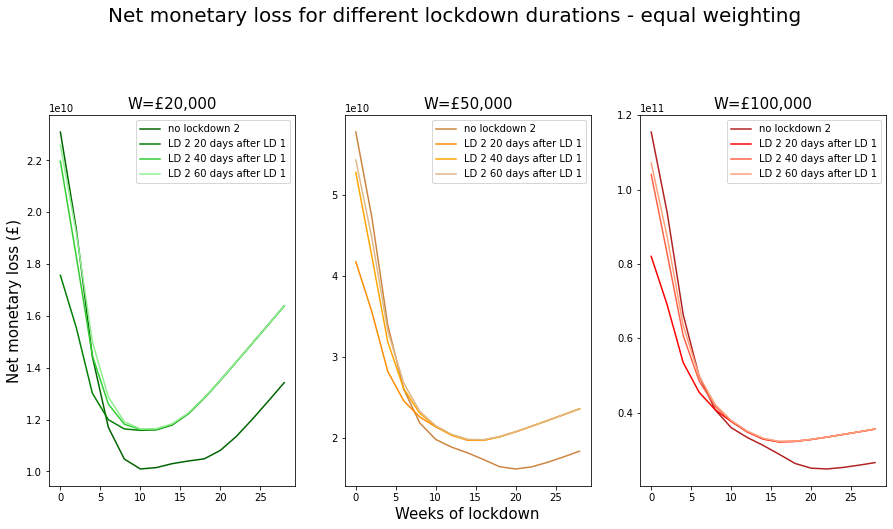

In [13]:
efficaciesArray = [0.5,0.7,0.9]
weights = [1/3, 1/3, 1/3]
days = 365
vaccineStart = 70
lockdown1Start = 40
outbreak2Start = days + 1 
weekStart = 0
weekEnd = 30
weekStep = 2
wks = np.arange(weekStart,weekEnd,weekStep)

LD1, LD2_20D, LD2_40D, LD2_60D = costsOverLockdowns(efficaciesArray, weights, vaccineStart, lockdown1Start, wks, outbreak2Start, days) 

# Plotting:
plt.figure(figsize=(15, 15))
plt.suptitle('Net monetary loss for different lockdown durations - equal weighting', fontsize=20)


plt.subplot(231)
plt.plot(wks, LD1[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, LD2_20D[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£)', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(232)
plt.plot(wks, LD1[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, LD2_20D[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.xlabel('Weeks of lockdown', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(233)
plt.plot(wks, LD1[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, LD2_20D[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.show()

## $w_1 = 0.6, w_2 = 0.2, w_3 = 0.2$   <a id="w1=0.6" ></a>

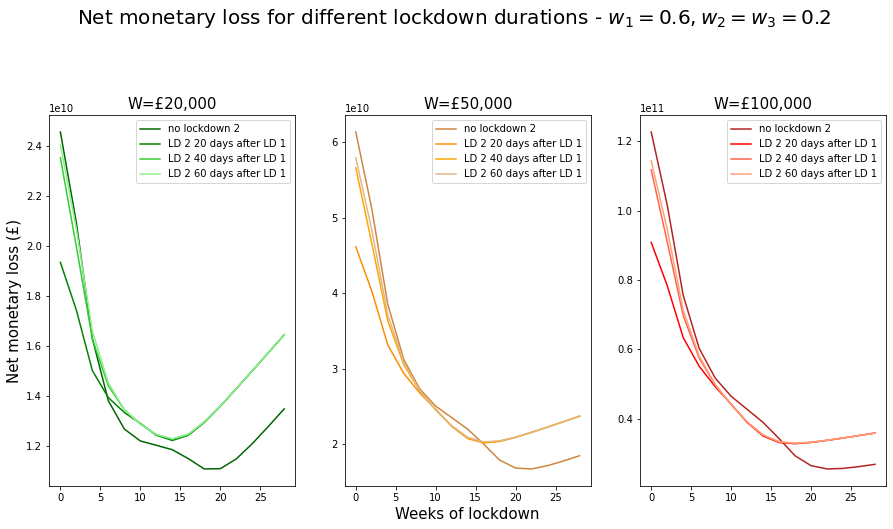

In [17]:
efficaciesArray = [0.5,0.7,0.9]
weights = [0.6, 0.2, 0.2]
days = 365
vaccineStart = 70
lockdown1Start = 40
outbreak2Start = days+1
weekStart = 0
weekEnd = 30
weekStep = 2
wks = np.arange(weekStart,weekEnd,weekStep)

LD1, LD2_20D, LD2_40D, LD2_60D = costsOverLockdowns(efficaciesArray, weights, vaccineStart, lockdown1Start, wks, outbreak2Start, days)

plt.figure(figsize=(15, 15))
plt.suptitle('Net monetary loss for different lockdown durations - $w_1 = 0.6, w_2=w_3 = 0.2$', fontsize=20)


plt.subplot(231)
plt.plot(wks, LD1[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, LD2_20D[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£)', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(232)
plt.plot(wks, LD1[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, LD2_20D[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.xlabel('Weeks of lockdown', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(233)
plt.plot(wks, LD1[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, LD2_20D[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.show()

## $w_1 = 0.2, w_2 = 0.6, w_3 = 0.2$   <a id="w2=0.6" ></a>

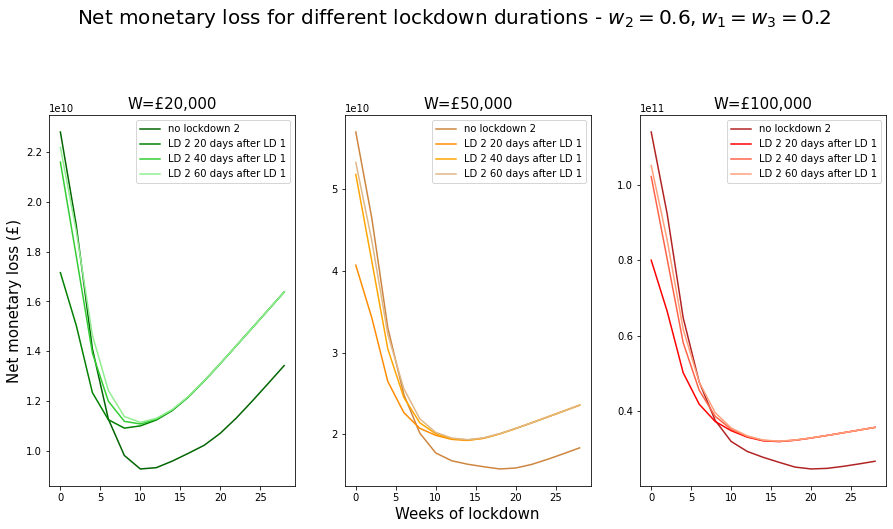

In [16]:
efficaciesArray = [0.5,0.7,0.9]
weights = [0.2,0.6,0.2]
days = 365
vaccineStart = 70
lockdown1Start = 40
outbreak2Start = days + 1
weekStart = 0
weekEnd = 30
weekStep = 2
wks = np.arange(weekStart,weekEnd,weekStep)

LD1, LD2_20D, LD2_40D, LD2_60D = costsOverLockdowns(efficaciesArray, weights, vaccineStart, lockdown1Start, wks, outbreak2Start, days)

plt.figure(figsize=(15, 15))
plt.suptitle('Net monetary loss for different lockdown durations - $w_2 = 0.6, w_1=w_3 = 0.2$', fontsize=20)


plt.subplot(231)
plt.plot(wks, LD1[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, LD2_20D[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£)', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(232)
plt.plot(wks, LD1[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, LD2_20D[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.xlabel('Weeks of lockdown', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(233)
plt.plot(wks, LD1[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, LD2_20D[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.show()

## $w_1 = 0.2, w_2 = 0.2, w_3 = 0.6$   <a id="w3=0.6" ></a>

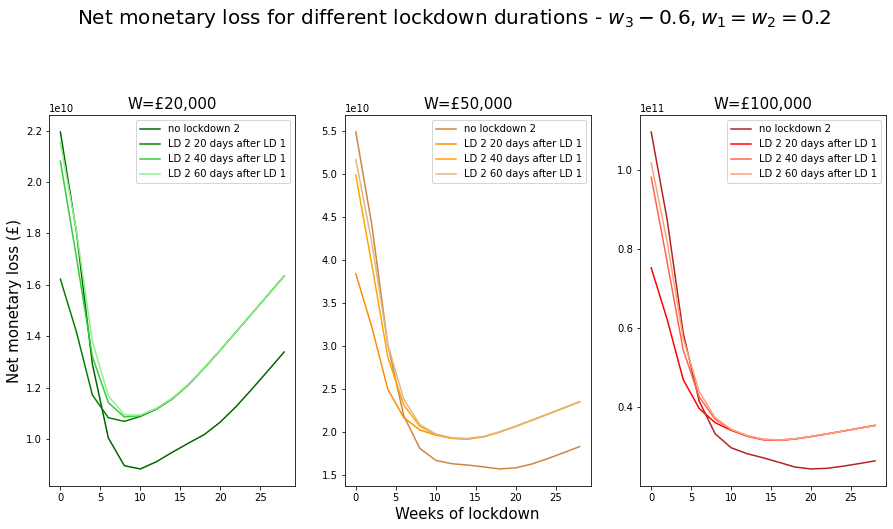

In [19]:
efficaciesArray = [0.5,0.7,0.9]
weights = [0.2,0.2, 0.6]
days = 365
vaccineStart = 70
lockdown1Start = 40
outbreak2Start = days + 1
weekStart = 0
weekEnd = 30
weekStep = 2
wks = np.arange(weekStart,weekEnd,weekStep)

LD1, LD2_20D, LD2_40D, LD2_60D = costsOverLockdowns(efficaciesArray, weights, vaccineStart, lockdown1Start, wks, outbreak2Start, days)

plt.figure(figsize=(15, 15))
plt.suptitle('Net monetary loss for different lockdown durations - $w_3 - 0.6, w_1=w_2=0.2$', fontsize=20)


plt.subplot(231)
plt.plot(wks, LD1[0], color = 'darkgreen', label = 'no lockdown 2')
plt.plot(wks, LD2_20D[0], color = 'green', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[0], color = 'limegreen', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[0], color = 'lightgreen', label = 'LD 2 60 days after LD 1')
plt.ylabel('Net monetary loss (£)', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£20,000', fontsize = 15)

plt.subplot(232)
plt.plot(wks, LD1[1], color = 'peru', label ='no lockdown 2')
plt.plot(wks, LD2_20D[1], color = 'darkorange', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[1], color = 'orange', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[1], color = 'burlywood', label = 'LD 2 60 days after LD 1')
plt.xlabel('Weeks of lockdown', fontsize = 15)
plt.legend(loc=0)
plt.title('W=£50,000', fontsize = 15)

plt.subplot(233)
plt.plot(wks, LD1[2], color = 'firebrick', label ='no lockdown 2')
plt.plot(wks, LD2_20D[2], color = 'red', label = 'LD 2 20 days after LD 1')
plt.plot(wks, LD2_40D[2], color = 'tomato', label = 'LD 2 40 days after LD 1')
plt.plot(wks, LD2_60D[2], color = 'lightsalmon', label = 'LD 2 60 days after LD 1')
plt.legend(loc=0)
plt.title('W=£100,000', fontsize = 15)

plt.show()

## Triangle Plots  <a id="triangleplots" ></a>

We can also plot information about the optimal lockdown for every single weighting combination, via a triangle plot. The weights $w_1, w_2, w_3$ will be on the three axis, and different lockdown scenarios will be colour coded within the triangle.
Since there are a lot of potential 'optimal lockdowns', I have split them into categories:

- No Lockdown (red)
- 1-5 weeks of lockdown (orange)
- 6-10 weeks of lockdown (yellow)
- 11-15 weeks of lockdown (green)
- 16-20 weeks of lockdown (blue)
- 21+ weeks of lockdown (pink)

First we need to define a function `QALY_GDParrays()` that returns the an array of the QALY and GDP loss for every length of lockdown. So `len(QALYarray) = len(GDParray) = len(wks)`.

Splitting it in this way minimises the number of times it needs to be called - as this is the function that takes time to run. The QALY and GDP loss is not dependent on the weighting of the vaccine efficacy - these weights only appear in the final line of the calculation (now found in the separate `totalCost()` function). Therefore this only needs to be called once in the function `optimalLockdownCategories()` when creating an array of costs for every weighting combiniation.

In [22]:
def QALY_GDParrays(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, wks, outbreak2Start, days):
    weekIncrement = wks[1]-wks[0]
    
    QALYarray = []
    GDParray = []
    
    if lockdown2 == True: #If there is a second lockdown:
        for i in wks:
            QALYs, GDP = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, lockdown1Start+i*7 + 40, lockdown1Start+i*7 + 68, outbreak2Start, days)
            
            QALYarray.append(QALYs)
            GDParray.append(GDP)
    else: #No second lockdown:
        for i in wks:  
            QALYs, GDP = QALY_GDPloss(allAgeGrpParams, efficaciesArray, vaccineStart, lockdown1Start, lockdown1Start+i*7, 0, 0, outbreak2Start, days)
            
            QALYarray.append(QALYs)
            GDParray.append(GDP)
    
    return(QALYarray, GDParray)

def get_category(weeks):
    if weeks == 0:
        return 0
    if 1 <= weeks <= 5:
        return 1
    if 6 <= weeks <= 10:
        return 2
    if 11 <= weeks <= 15:
        return 3
    if 16 <= weeks <= 20:
        return 4
    else:
        return 5
    
def optimalLockdownCategories(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, W, wks, n, outbreak2Start, days):
    QALYarray, GDParray = QALY_GDParrays(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, wks, outbreak2Start, days)
    
    weekIncrement = wks[1] - wks[0]
    w1,w2,w3 = [],[],[]
    results = []
    
    for i in range(n + 1):
        for j in range(n + 1 - i):
            k = n - i - j

            v1, v2, v3 = i/n, j/n, k/n
            w1.append(v1)
            w2.append(v2)
            w3.append(v3)
            
            costArray = []
            for l in range(len(wks)):
                costArray.append(totalCost(W, QALYarray[l], GDParray[l], [v1,v2,v3]))

            optimalLockdown = costArray.index(min(costArray))*weekIncrement
            results.append(get_category(optimalLockdown))

    return(w1,w2,w3, results)

In [23]:
efficaciesArray = [0.5, 0.7, 0.9]
days = 365
vaccineStart = 70
lockdown1Start = 40
lockdown2 = False  #T or F depending on if there is a second lockdown
n = 10
outbreak2Start = 366
days = 365
weekStart, weekEnd, weekIncrement = 0, 30, 2 
wks = np.arange(weekStart, weekEnd, weekIncrement)



w11, w21, w31, resultsW1 = optimalLockdownCategories(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 20000, wks, n, outbreak2Start, days)
w12, w22, w32, resultsW2 = optimalLockdownCategories(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 50000, wks, n, outbreak2Start, days)
w13, w23, w33, resultsW3 = optimalLockdownCategories(efficaciesArray, vaccineStart, lockdown1Start, lockdown2, 100000, wks, n, outbreak2Start, days)

### Willingness to pay £20,000 <a id = 'w=20k' ><a>

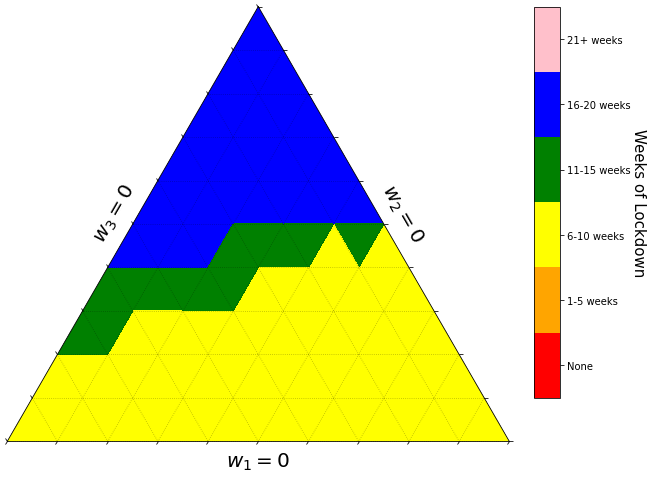

In [24]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(projection='ternary')

plot = ax.tripcolor(w11, w21, w31, resultsW1, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')

ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")


plt.show()

### Willingness to pay £50,000 <a id = 'w=50k' ><a>

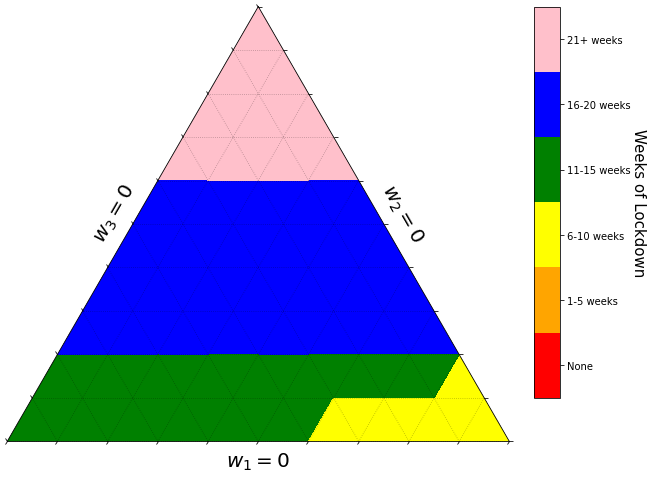

In [25]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(projection='ternary')

plot = ax.tripcolor(w12, w22, w32, resultsW2, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")


plt.show()

### Willingness to pay £100,000 <a id = 'w=100k' ><a>

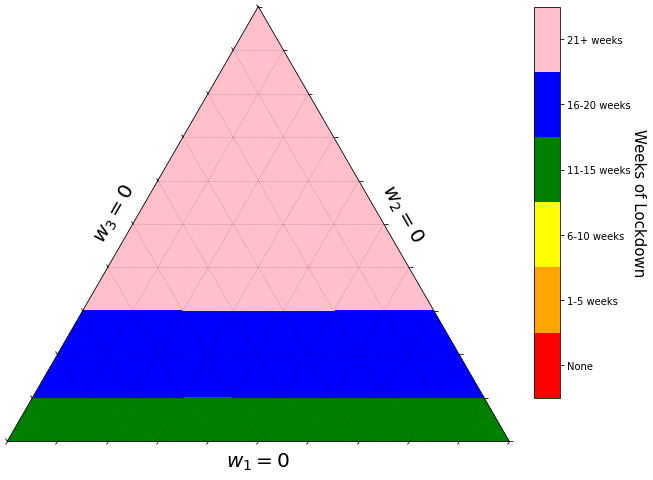

In [26]:
colors = ['red', 'orange', 'yellow', 'green', 'blue', 'pink']
cmap = mcolors.ListedColormap(colors)
bounds = [0, 1, 2, 3, 4, 5, 6] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(projection='ternary')

plot = ax.tripcolor(w13, w23, w33, resultsW3, cmap=cmap, norm=norm, shading='flat')
ax.set_tlabel('$w_2 = 0$', fontsize=20)
ax.set_llabel('$w_3 = 0$', fontsize=20)
ax.set_rlabel('$w_1 = 0$', fontsize=20)
ax.taxis.set_label_position('tick1')
ax.laxis.set_label_position('tick1')
ax.raxis.set_label_position('tick1')
ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax.taxis.set_ticks(ticks)
ax.laxis.set_ticks(ticks)
ax.raxis.set_ticks(ticks)
ax.taxis.set_ticklabels([])
ax.laxis.set_ticklabels([])
ax.raxis.set_ticklabels([])

ax.grid(True, linestyle=':', color='black', alpha=0.3)


cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(plot, cax=cax, ticks=[0.5,1.5,2.5,3.5,4.5, 5.5])
colorbar.ax.set_yticklabels(['None', '1-5 weeks', '6-10 weeks', '11-15 weeks', '16-20 weeks', '21+ weeks'])
colorbar.set_label("Weeks of Lockdown", rotation=270, fontsize = 15, va="baseline")


plt.show()